# Week 1 · GPT-2의 Residual Stream과 Transformer Circuits

**스터디 범위:** *A Mathematical Framework for Transformer Circuits*의 도입부터
**One-Layer Attention-Only Transformers**까지. Two-Layer 및 induction-head 이론은 다음 주로 남긴다.

**이번 실험:** 실제 GPT-2 small (12 layers, 12 heads, $d_{model}=768$, $d_{head}=64$)에
문장을 넣고 768차원 상태가 어디에서 어떻게 바뀌는지 관찰한다. 별도의 작은 수식 예제로
one-layer attention-only 분해를 검증한다. 실제 모델을 one-layer 모델로 부르지 않는다.

**학습 목표**
1. residual stream을 각 위치의 벡터에 모듈들이 값을 더하는 공유 공간으로 설명한다.
2. QK의 정보 선택과 OV의 정보 변환을 구분한다.
3. 레이어 깊이, 문장 내 토큰 위치, 자기회귀 생성 시간을 구분한다.
4. 그림의 인상과 수치 검증, 인과적 주장을 구분한다.

권장 진행: 개념 20분 → residual 실험 25분 → QK/OV 25분 → one-layer 수식/토론 20분.
원문을 대체하는 번역문이 아니라 직접 실행하며 사용하는 실험 노트다.


## 0. 실행 환경과 재현성

RTX 5090의 WSL Python 커널에서 **Restart Kernel → Run All**로 실행한다.
설치는 저장소 README 참고. GPU가 없으면 조용히 CPU로 바꾸지 않고 오류를 낸다.
모델은 eval/float32, greedy decoding, 고정 revision을 사용한다. 학습은 하지 않는다.

`PROMPT`와 `NEW_TOKENS`를 바꾸고 아래 셀부터 다시 실행하면 새 입력을 관찰할 수 있다.
GPT-2는 영어 중심 모델이고 BPE 토큰은 단어와 다르다. 한국어도 입력할 수 있지만
잘린 UTF-8 조각은 `�`로 표시될 수 있으므로 토큰 ID와 위치를 함께 확인한다.

GitHub 미리보기는 PNG와 수치 결과를 볼 수 있다. Play/슬라이더는 신뢰한 Jupyter 노트북
또는 `artifacts/week01-interactive.html`에서 동작한다. HTML은 Plotly를 포함해 오프라인에서도 열린다.
노트북 내 동적 출력은 Plotly CDN을 사용한다.


In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd()
if not (ROOT / "study.py").exists():
    ROOT = ROOT.parent
assert (ROOT / "study.py").exists(), "Run from the repository or notebooks directory."
sys.path.insert(0, str(ROOT))
import numpy as np
import torch
from IPython.display import display, HTML, Image
import study
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
PROMPT = "When Mary and John went to the store, John gave a drink to"
NEW_TOKENS = 6
LAYER = 0
HEAD = 0
model, tokenizer = study.load_model()
print(torch.cuda.get_device_name(), next(model.parameters()).dtype)
print(f"layers={model.config.n_layer}, heads={model.config.n_head}, residual={model.config.n_embd}")


`torch_dtype` is deprecated! Use `dtype` instead!


NVIDIA GeForce RTX 5090 torch.float32
layers=12, heads=12, residual=768


## 1. Residual stream은 어디에 있는가?

배치 축을 제외하면 $R\in\mathbb{R}^{T\times768}$. 각 행은 한 토큰 **위치**의 상태다.
초기 상태는 토큰 임베딩과 학습된 위치 임베딩의 합이다.

$$R_0=E[token]+P[position]$$
$$R_{\ell,mid}=R_{\ell,pre}+Attention_\ell(LN_{1,\ell}(R_{\ell,pre}))$$
$$R_{\ell,post}=R_{\ell,mid}+MLP_\ell(LN_{2,\ell}(R_{\ell,mid}))$$

블록 사이에는 $R_{\ell+1,pre}=R_{\ell,post}$이다. 마지막에는
$logits=LN_f(R_{11,post})W_U$. $LN_f$는 마지막 residual 업데이트가 아니라 읽기 전 정규화다.

이 노트북은 **초기 상태 1개 + 12블록 × (attention 이후, MLP 이후) = 25개 상태**를 저장한다.
Hugging Face의 `hidden_states[-1]`은 마지막 LayerNorm 이후라서 그대로 raw residual로
취급하면 안 된다. 여기서는 블록과 서브모듈 hook으로 직접 수집한다.

MLP는 위치별로 계산하고, attention은 다른 위치의 정보를 읽는다. 둘 다 같은 768차원 공간에
쓴다. 개별 좌표를 바로 “성별”, “이름” 같은 의미로 해석할 근거는 없다.


In [2]:
runs, prefix_error = study.experiment(model, tokenizer, PROMPT, NEW_TOKENS)
run = runs[0]
print("Input:", run["text"])
print("Generated:", runs[-1]["text"])
print("Residual shape [stage, token, coordinate]:", run["residual"].shape)
for token_id, label in zip(run["ids"], run["labels"]):
    print(f"{token_id:5d}  {label}")
print("Numerical checks:", run["errors"])


Input: When Mary and John went to the store, John gave a drink to
Generated: When Mary and John went to the store, John gave a drink to Mary and said, "Mary
Residual shape [stage, token, coordinate]: (25, 14, 768)
 2215  0: 'When'
 5335  1: ' Mary'
  290  2: ' and'
 1757  3: ' John'
 1816  4: ' went'
  284  5: ' to'
  262  6: ' the'
 3650  7: ' store'
   11  8: ','
 1757  9: ' John'
 2921  10: ' gave'
  257  11: ' a'
 4144  12: ' drink'
  284  13: ' to'
Numerical checks: {'attention_pattern': 0.0, 'attention_output': 0.000732421875, 'residual_sum': 0.0}


### 먼저 전체 크기를 본다

왼쪽 그림은 위치별 $\|R\|_2$, 오른쪽은 각 모듈이 **추가한 벡터**의 평균 크기다.
residual 자체의 크기와 업데이트 크기는 다르다. 큰 업데이트가 반드시 중요한 것도 아니다.
두 업데이트가 상쇄되거나 출력에 덜 민감한 방향으로 움직일 수 있다.
색 범위는 한 그림 안에서 고정된다. 첫 레이어/헤드 선택은 설명을 위한 기본값이며,
이 문장에 가장 중요한 회로를 발견했다는 뜻이 아니다.


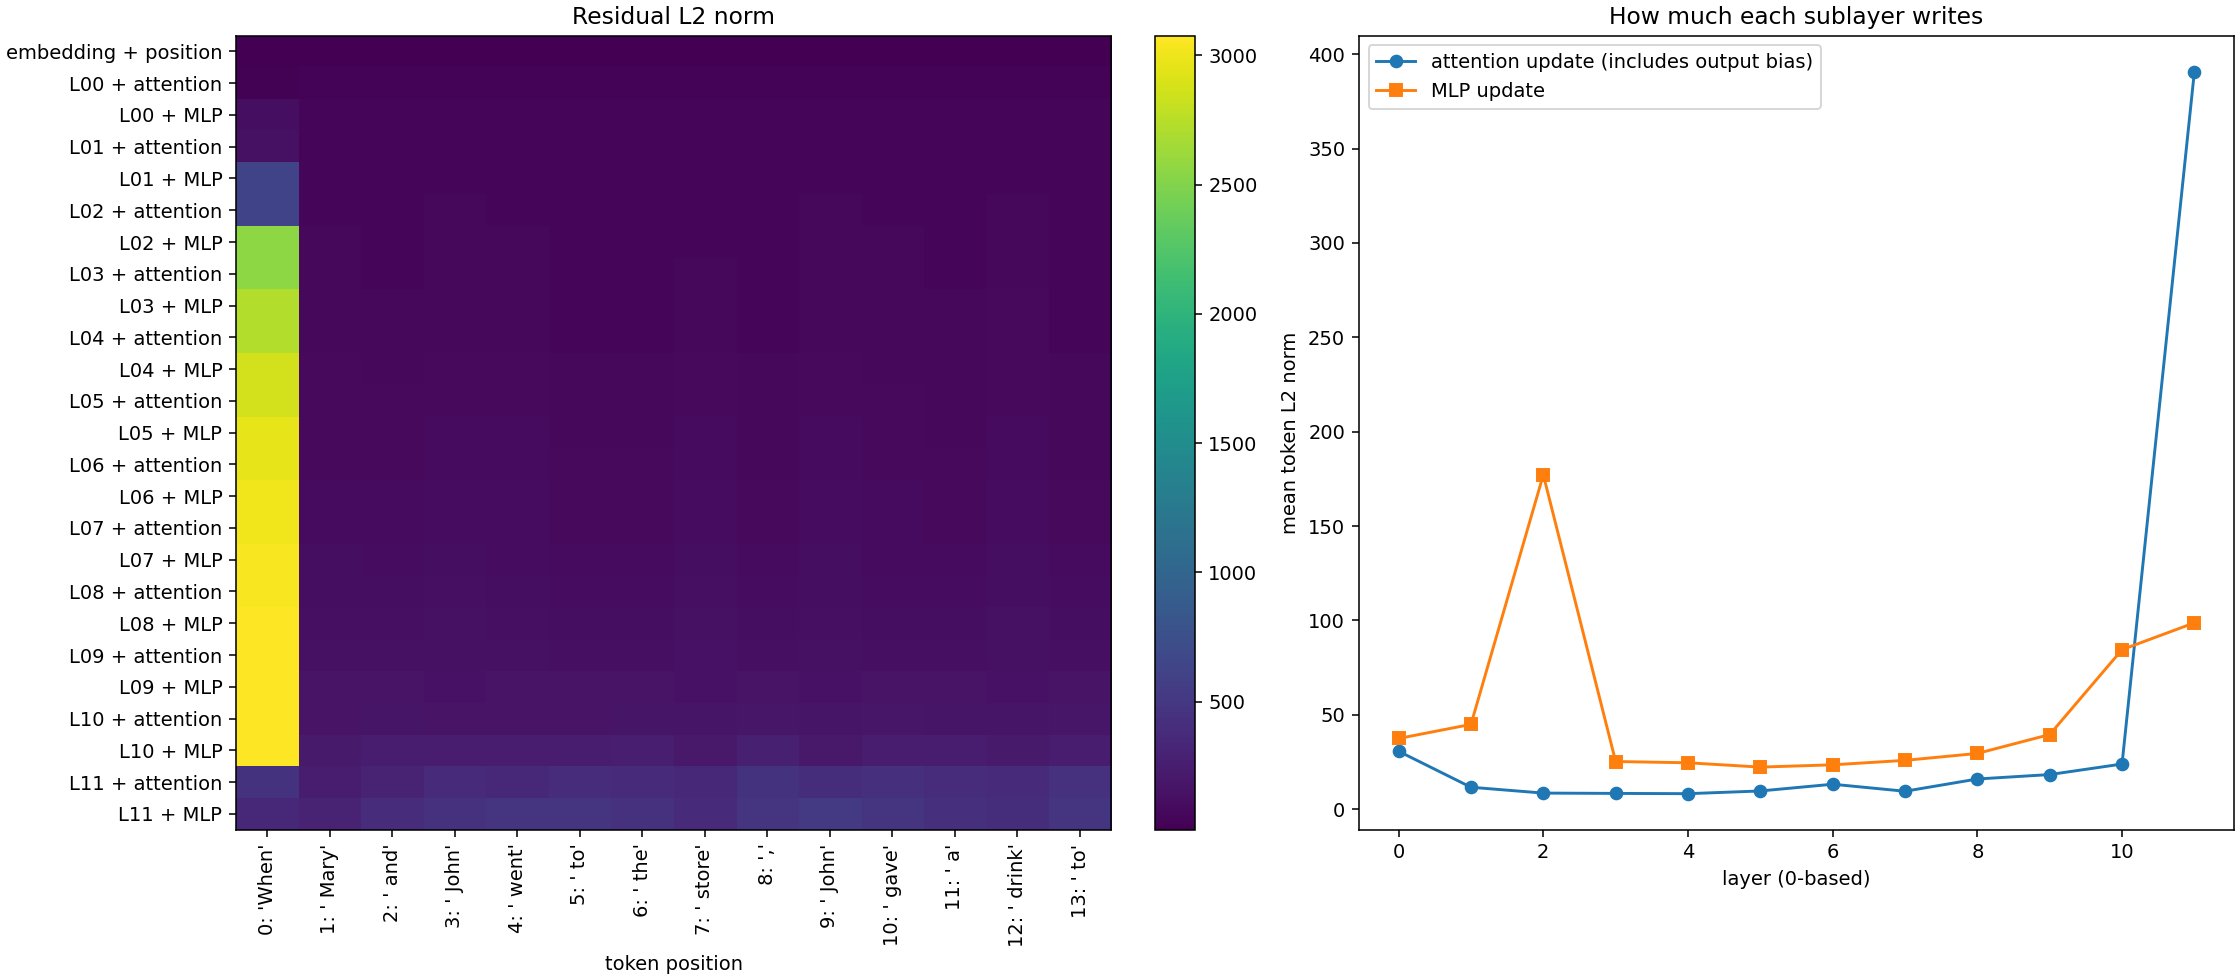

In [3]:
study.save_static(run, ARTIFACTS)
display(Image(filename=str(ARTIFACTS / "residual-summary.png")))


### 768개 좌표 그대로 보기: 깊이 애니메이션

가로축은 768 residual 좌표, 세로축은 입력 토큰 위치다. Play 또는 depth 슬라이더로
초기 임베딩 → attention 덧셈 → MLP 덧셈을 따라간다. E는 초기 상태, A/M은 attention/MLP 이후다.
모든 프레임은 같은 색 범위를 쓴다. 큰 이상값 때문에 나머지가 안 보이지 않도록 색은
$sign(x)\log(1+|x|)$로 표시하고, **hover에는 변환 전 activation**을 표시한다.
`study.residual_movie(run, scale="raw")`로 선형 색상을 볼 수 있다. 값의 크기를 색 차이와
선형적으로 대응시키면 안 된다.

관찰 질문: 어느 층에서 변화가 큰가? 동일한 `John`도 위치에 따라 상태가 같은가?
768개 좌표의 패턴만으로 의미를 확정할 수 있는가?


In [4]:
def show(fig):
    display(HTML(study.figure_html(fig)))
residual_fig = study.residual_movie(run)
show(residual_fig)


### 공통 PCA 좌표계에서 토큰의 경로 보기

모든 깊이·생성 단계의 residual을 모아 **한 번만** PCA를 적합한다. 각 토큰의 선은 깊이에
따른 경로이고 hover는 서브레이어를 보여준다. 프레임마다 PCA를 새로 맞추면 축 자체가
회전하므로 이동을 비교할 수 없다. 여기서는 같은 중심과 기저를 쓴다.

PCA는 큰 분산을 보존하는 투영이다. 아래 분산 보존율이 낮으면 3D 그림에서 가까운 점이
768차원에서 가깝다고 말할 수 없다. PCA 축에 자동으로 의미 이름을 붙이지 않는다.
전체 궤적을 본 뒤 맞춘 좌표이므로 온라인 예측 분석도 아니다.
기본 입력에서는 첫 토큰의 큰 activation이 분산을 지배한다. 높은 분산 보존율만으로
다른 토큰의 세밀한 차이까지 잘 보인다고 결론내리지 않는다.


In [5]:
mean, basis, variance = study.fit_projection(runs)
print("Explained variance per PC:", variance, "total:", variance.sum())
trajectory_fig = study.trajectory(run, mean, basis, variance)
show(trajectory_fig)


Explained variance per PC: [0.9543031  0.02603081 0.00467812] total: 0.98501205


## 2. '시간에 따라 변한다'는 말의 세 가지 의미

| 축 | 무엇이 변하는가? | 이 실험의 표시 |
|---|---|---|
| 깊이 $\ell$ | 동일 입력의 상태가 서브레이어를 통과 | 25개 residual 단계 |
| 위치 $t$ | 동일 문장의 서로 다른 토큰 | heatmap 행/열과 토큰 라벨 |
| 생성 step $s$ | 접두사에 새 토큰이 추가 | 다음 애니메이션의 프레임 |

causal mask 때문에 뒤에 토큰을 추가해도 **기존 위치의 상태는 변하지 않는다**.
수치 계산 오차를 제외하면 이전 프레임의 영역이 고정이고 새 열만 나타나야 한다.
새로 생긴 마지막 위치의 벡터와 이전 마지막 위치의 벡터를 비교할 때는 서로 다른 위치라는
점을 기억한다. 이것은 학습 시간이나 wall-clock 속도 측정이 아니다.

교육용으로 매 step 전체 prefix를 다시 계산한다(`use_cache=False`). 실제 서빙의 KV cache
최적화와 구별하기 위한 선택이며, 짧은 문장만 사용한다. greedy가 EOS를 골라도 이 실험은
지정한 step 수만큼 이어서 관측한다.


In [6]:
print("Old-prefix residual max absolute change:", prefix_error)
for step, item in enumerate(runs):
    print(step, repr(item["text"]))
time_fig = study.generation_movie(runs)
show(time_fig)


Old-prefix residual max absolute change: 0.00048828125
0 'When Mary and John went to the store, John gave a drink to'
1 'When Mary and John went to the store, John gave a drink to Mary'
2 'When Mary and John went to the store, John gave a drink to Mary and'
3 'When Mary and John went to the store, John gave a drink to Mary and said'
4 'When Mary and John went to the store, John gave a drink to Mary and said,'
5 'When Mary and John went to the store, John gave a drink to Mary and said, "'
6 'When Mary and John went to the store, John gave a drink to Mary and said, "Mary'


## 3. Attention을 QK와 OV로 분리하기

이 노트북은 **행벡터** 표기다. 원문의 열벡터 표기와 행렬 곱 순서가 반대일 수 있다.
한 head에서 $X=LN_1(R)$라고 두면:

$$Q=XW_Q+b_Q,\quad K=XW_K+b_K,\quad V=XW_V+b_V$$
$$S_{ij}=Q_iK_j^T/\sqrt{64},\quad A=softmax(S+M)$$
$$O^h_i=\sum_{j\le i} A^h_{ij}(V^h_jW^h_O)$$

행 $i$는 정보를 받는 **destination**, 열 $j$는 정보를 주는 **source**다.
미래 위치는 mask로 제외된다. QK는 *어디를 읽을지*, OV는 *읽은 것을 어떤 벡터로 쓸지*를
결정한다. attention 가중치만 보아서는 출력의 크기·방향·부호를 알 수 없다.

$W_{QK}=W_QW_K^T$와 $W_{OV}=W_VW_O$는 각각 $768\times768$의 **고정 가중치 곱**이다.
아래 움직이는 그림은 그 가중치 자체가 아니라 입력에 따른 QK 점수와 OV 쓰기 벡터다.
GPT-2의 bias 때문에 실제 식은 순수한 두 행렬 곱보다 항이 더 있다.

모든 head 출력을 더한 뒤 attention 출력 bias를 **한 번** 더한다:
$Attention(X)=\sum_h O^h+b_O$. $b_V$는 각 head의 OV에 포함하고 $b_O$는 head별로 중복 배분하지 않는다.
dropout은 eval 상태에서 꺼져 있다.


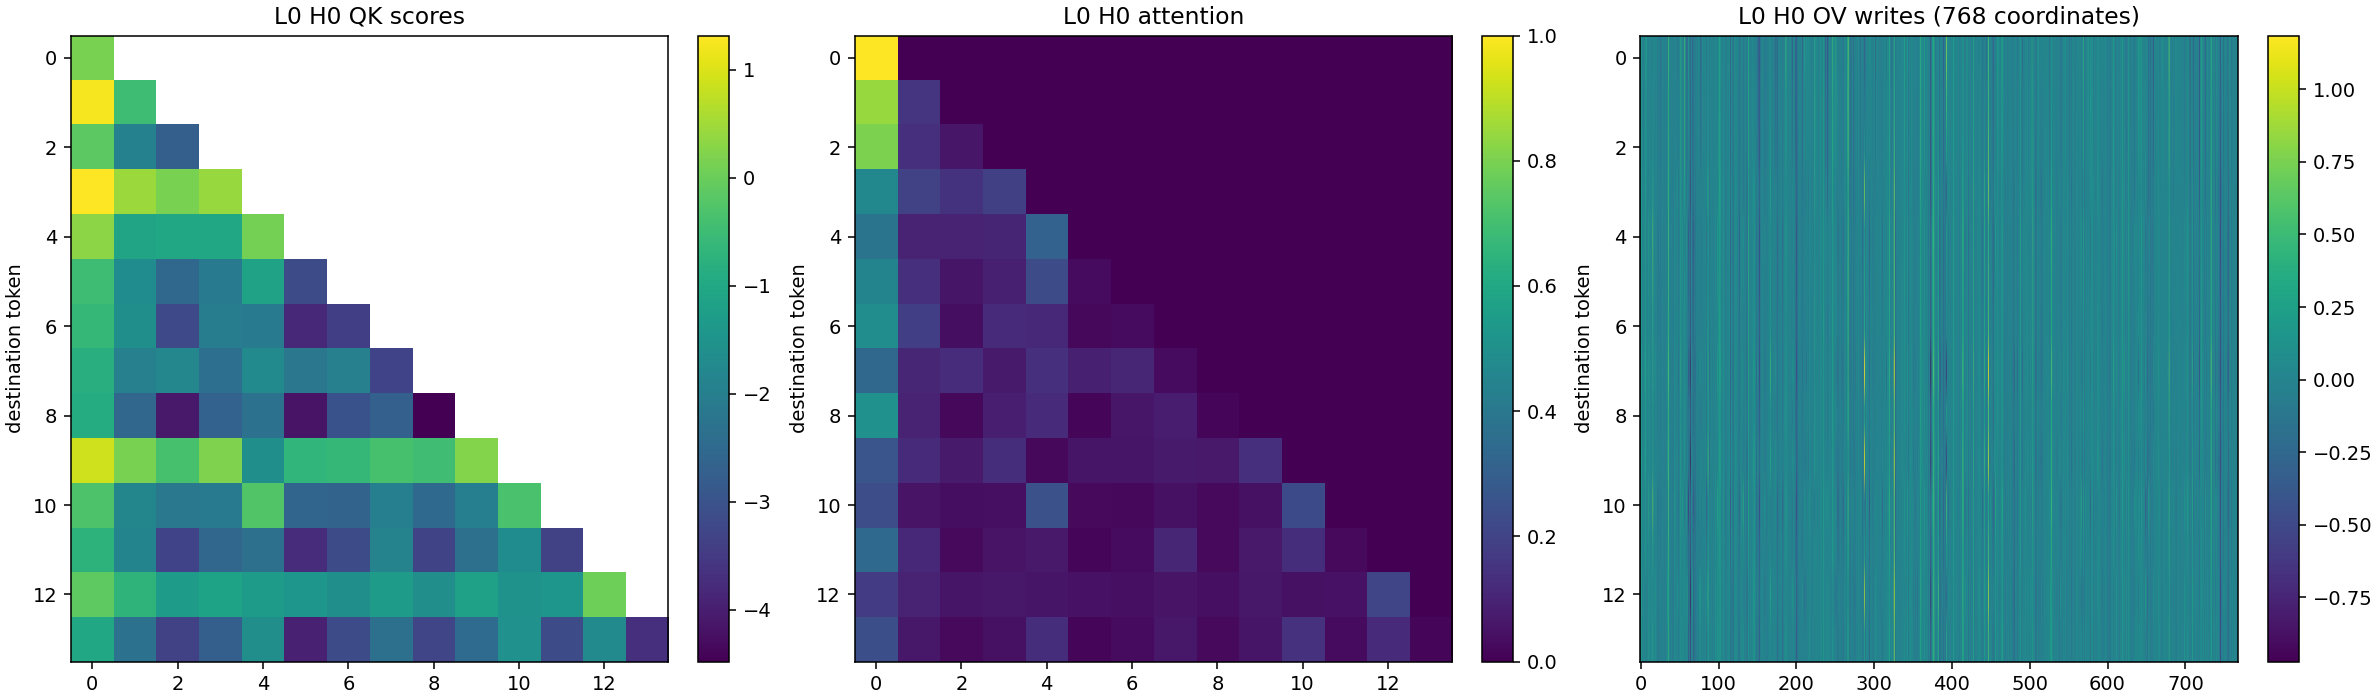

In [7]:
display(Image(filename=str(ARTIFACTS / "circuits-summary.png")))
circuit_fig = study.circuit_movie(runs, LAYER, HEAD)
show(circuit_fig)


### 레이어·헤드 선택과 source별 OV 기여

아래 선택기는 GPU 계산 없이 저장된 activation을 사용한다. 12×12 조합을 바꿔 보고
`Render selected head` 버튼을 누른 후 생성 슬라이더를 움직인다.
첫 두 그림의 색 범위는 각각 고정된 QK 범위와 $[0,1]$,
세 번째는 고정된 OV 범위다. 서로 다른 단위의 패널 색을 직접 비교하지 않는다.

source별 그림은 마지막 destination에 각 source가 쓴 $A_{ij}V_jW_O$다.
source 축으로 합하면 해당 head의 출력 벡터가 되어야 한다. 음의 값도 정상이다.


In [8]:
import ipywidgets as widgets
def inspect_head(layer=0, head=0):
    show(study.circuit_movie(runs, layer, head))
    show(study.source_contributions(runs[0], layer, head, len(runs[0]["ids"])-1))
controls = widgets.interactive(inspect_head, {"manual": True, "manual_name": "Render selected head"},
    layer=widgets.IntSlider(min=0,max=11,value=LAYER,description="Layer",continuous_update=False),
    head=widgets.IntSlider(min=0,max=11,value=HEAD,description="Head",continuous_update=False))
display(controls)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Layer', max=11), IntSlider(valu…

### 고정 가중치 곱과 입력 의존 패턴 비교

가중치 곱은 이 생성 실험 동안 변하지 않는다. 아래는 선택된 head의 QK/OV를 직접
구성하고 rank의 상한이 head dimension 64임을 보여준다. bias와 LayerNorm을 생략한
이 곱을 앞의 실제 activation heatmap과 혼동하지 않는다.


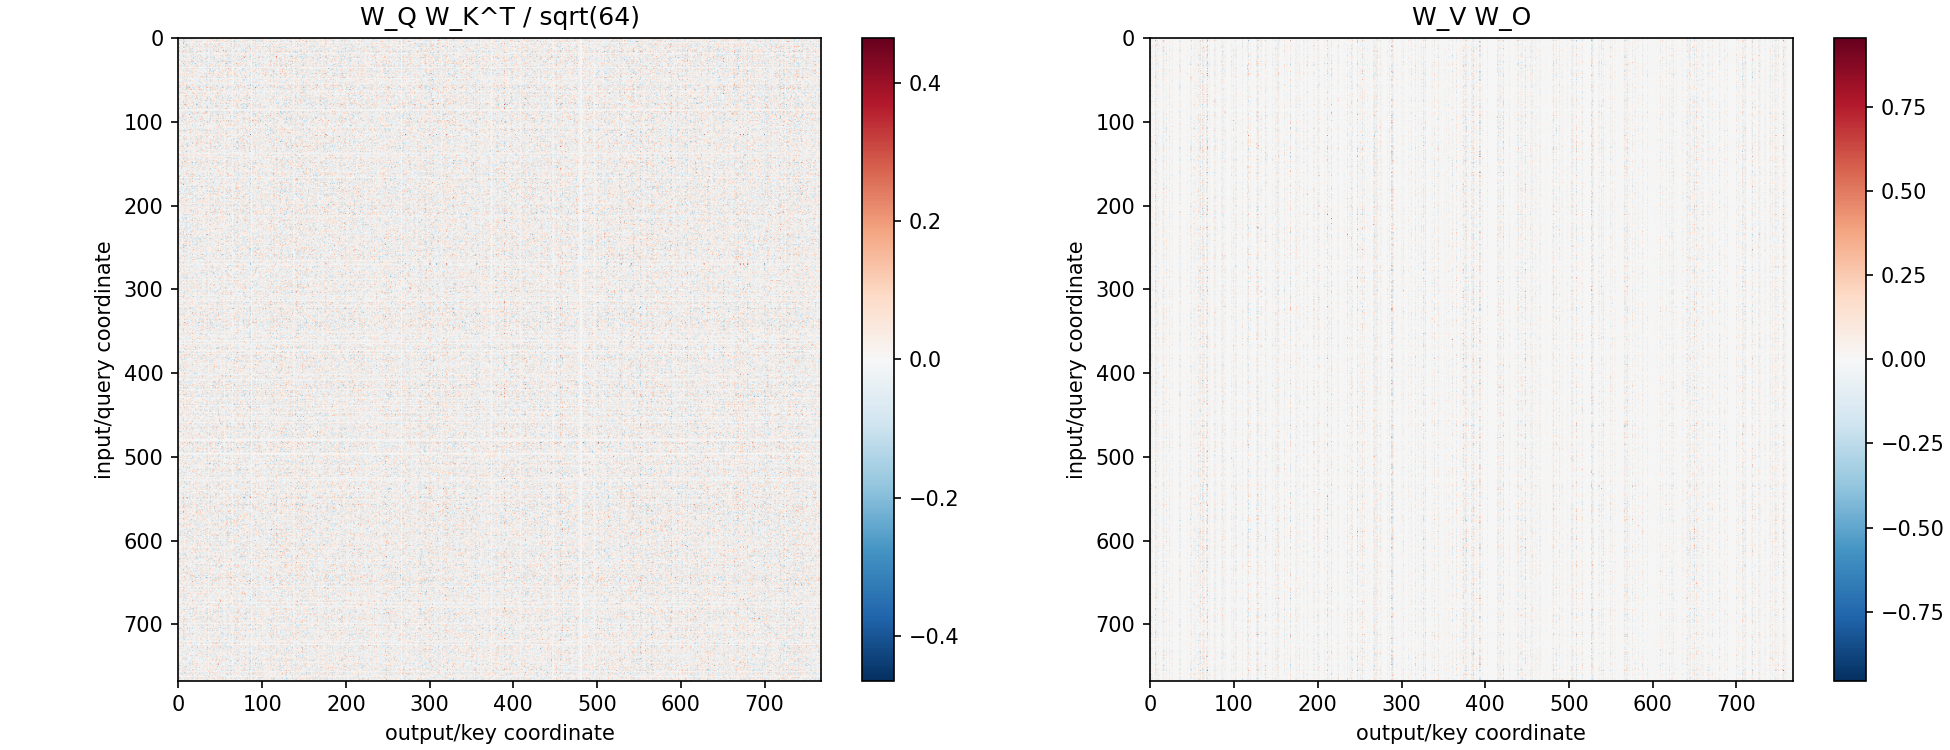

Both maps factor through a 64-dimensional head space; rank <=64.


In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
attn = model.transformer.h[LAYER].attn
weight = study.cpu(attn.c_attn.weight)
wq, wk, wv = np.split(weight, 3, axis=1)
sl = slice(HEAD*64, (HEAD+1)*64)
wo = study.cpu(attn.c_proj.weight)[sl]
wqk = wq[:,sl] @ wk[:,sl].T / np.sqrt(64)
wov = wv[:,sl] @ wo
weight_fig = make_subplots(rows=1, cols=2, subplot_titles=("W_Q W_K^T / sqrt(64)", "W_V W_O"))
for column, matrix in enumerate([wqk, wov], start=1):
    # 768x768 matrices are shown at full resolution, with independent scales.
    weight_fig.add_trace(go.Heatmap(z=matrix,colorscale="RdBu",zmid=0,showscale=False),row=1,col=column)
weight_fig.update_layout(height=550,title=f"Fixed weights: layer {LAYER}, head {HEAD}")
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
for ax, matrix, title in zip(axes,[wqk,wov],["W_Q W_K^T / sqrt(64)","W_V W_O"]):
    bound = np.abs(matrix).max()
    im = ax.imshow(matrix,cmap="RdBu_r",vmin=-bound,vmax=bound)
    ax.set(title=title,xlabel="output/key coordinate",ylabel="input/query coordinate")
    fig.colorbar(im,ax=ax)
fig.savefig(ARTIFACTS / "fixed-weights.png",dpi=150)
plt.close(fig)
display(Image(filename=str(ARTIFACTS / "fixed-weights.png")))
# Optional interactive rendering of all weights: show(weight_fig)
print("Both maps factor through a 64-dimensional head space; rank <=64.")


## 4. Residual을 어휘 공간에서 읽기: logit lens

각 단계의 마지막 위치에 최종 $LN_f$와 unembedding을 적용한다.
마지막 단계는 실제 모델 logits와 일치해야 한다. 중간 단계에는 이 readout을 위해
학습된 보장이 없으므로 **진단용 탐침**이다. 모델이 그 순간 해당 단어를 확신했다고
해석하지 않는다. 후보는 최종 단계 top-8로 고정한다. 표는 확률이 아닌 logits다.

특히 최종 LayerNorm의 평균·분산이 입력에 의존하므로, head의 $O^hW_U$를
실제 최종 logits에 대한 정확한 가산 기여라고 부를 수 없다.


In [10]:
lens_fig = study.logit_lens(model, run, tokenizer)
show(lens_fig)


## 5. Zero-layer에서 One-Layer Attention-Only까지

먼저 위치 임베딩, bias, LayerNorm, MLP를 생략한 단순 모델을 생각한다.
토큰 one-hot 행렬을 $T$, 임베딩을 $W_E$라고 하면 $X=TW_E$.
zero-layer의 logits는 $TW_EW_U$이므로 현재 토큰에서 다음 토큰으로의 직접 경로다.

한 층의 attention만 넣으면:

$$logits=TW_EW_U+\sum_h A^hTW_EW_V^hW_O^hW_U$$

직접 경로와 head 경로의 합이라는 것이 핵심이다. vocabulary 공간으로 펼치면
$C_{QK}=W_EW_QW_K^TW_E^T/\sqrt{d_h}$,
$C_{OV}=W_EW_VW_OW_U$. 전자는 destination/source 조합의 점수,
후자는 source/output 조합의 logit 변화를 표현한다.

`[source] ... [destination] [output]`의 세 토큰을 생각하면 QK가 source를 선택하고
OV가 output 후보를 바꾼다. 원문은 이를 skip-trigram 관점으로 설명한다.
softmax 분모는 prefix 전체에 의존하므로 독립적인 trigram 빈도표와 정확히 같지는 않다.

아래 작은 모델은 **설명용으로 직접 정한 가중치**다. GPT-2를 자르거나 학습한 모델이 아니다.
`Alice said`에서 `said`가 `Alice`를 읽고 `hello` logit을 올리도록 설계했다.
이를 통해 분해의 대수적 정확성을 확인할 수 있지만 GPT-2가 동일한 회로를 학습했다는
증거는 얻을 수 없다. 원문 실험의 재현이나 학습 결과 재현을 주장하지 않는다.


In [11]:
toy_fig, toy = study.one_layer_demo()
show(toy_fig)
print(json.dumps(toy, indent=2))
assert toy["max_decomposition_error"] < 1e-12


{
  "vocab": [
    "Alice",
    "Bob",
    "said",
    "hello",
    "goodbye"
  ],
  "input": "Alice said",
  "attention": [
    [
      1.0,
      0.0
    ],
    [
      0.9982804318220542,
      0.0017195681779457815
    ]
  ],
  "direct": [
    [
      1.0,
      0.0,
      0.0,
      0.0,
      0.0
    ],
    [
      0.0,
      0.0,
      1.0,
      0.0,
      0.0
    ]
  ],
  "head": [
    [
      0.0,
      0.0,
      0.0,
      4.0,
      0.0
    ],
    [
      0.0,
      0.0,
      0.0,
      3.9931217272882167,
      0.0
    ]
  ],
  "logits": [
    [
      1.0,
      0.0,
      0.0,
      4.0,
      0.0
    ],
    [
      0.0,
      0.0,
      1.0,
      3.9931217272882167,
      0.0
    ]
  ],
  "max_decomposition_error": 0.0
}


### GPT-2에 적용할 때 달라지는 부분

| 단순 one-layer 모델 | 실제 GPT-2 실험 |
|---|---|
| attention만 한 층 | attention+MLP 블록 12개 |
| token embedding만 가정 | token+position embedding |
| 선형 경로의 합 | LayerNorm, MLP 비선형성이 포함됨 |
| bias 생략 | Q/K/V 및 output bias 포함 |
| 작은 어휘로 전체 회로 확인 | 50,257 어휘: 전체 어휘 쌍 행렬은 만들지 않음 |

GPT-2 첫 블록의 attention만 관찰해도 원문의 순수한 one-layer attention-only 모델과 같지 않다.
여기서는 전체 GPT-2 안의 실제 연산을 hook으로 검증하고, 대수적 단순 모델은 별도로 검증한다.
다층 head composition의 해석은 이번 주 범위 밖이다.


## 6. 스터디 실습과 해석의 한계

1. `PROMPT = "The capital of France is"`로 바꾼 뒤 실행한다. attention/MLP 중 어느 단계에서
   최종 후보의 logit이 바뀌는가? 변화 크기와 정답 확률 변화는 같은가?
2. `John`을 `Mary`로 교체한다. BPE 길이가 달라지면 같은 위치 비교가 어긋나므로 토큰 표부터 확인한다.
3. 같은 head에서 QK가 큰 source와 OV 기여가 큰 source가 같은지 본다. attention만으로 설명이 충분한가?
4. 생성 애니메이션에서 이전 위치가 고정되는 이유를 causal mask로 설명한다.
5. toy 모델의 `Alice`와 `Bob`을 바꾸려면 `study.one_layer_demo`의 ids를 어떻게 바꾸어야 하는가?
   직접 경로와 head 경로를 따로 예측한 후 실행해 본다.

**이번에 얻는 것은 관측과 대수 검증이다.** activation patching/ablation으로 인과성을 검증하지
않았고, 한 문장의 한 head 패턴은 일반적인 기능을 입증하지 않는다. PCA·norm·logit lens는
서로 다른 요약이며 어느 하나도 모델의 의미를 완전히 설명하지 않는다.


In [12]:
report_figures = [residual_fig, trajectory_fig, time_fig, circuit_fig,
                   study.source_contributions(run,LAYER,HEAD,len(run["ids"])-1),lens_fig,toy_fig]
study.save_report(report_figures, ARTIFACTS / "week01-interactive.html")
evidence = study.metadata(model,PROMPT,runs,prefix_error)
evidence["pca_explained_variance"] = variance.tolist()
evidence["toy_decomposition_error"] = toy["max_decomposition_error"]
(ARTIFACTS / "validation.json").write_text(json.dumps(evidence,indent=2),encoding="utf-8")
np.savez_compressed(ARTIFACTS / "prompt-activations.npz",
    residual=run["residual"],attention=run["attention"],qk_scores=run["scores"],
    head_writes=run["head_writes"],source_ov=run["source_ov"],token_ids=run["ids"])
print(json.dumps(evidence,indent=2))
print("Saved offline interactive report and validation evidence to",ARTIFACTS)


{
  "model": "openai-community/gpt2",
  "revision": "607a30d783dfa663caf39e06633721c8d4cfcd7e",
  "device": "NVIDIA GeForce RTX 5090",
  "python": "3.10.12",
  "torch": "2.9.1+cu128",
  "cuda": "12.8",
  "packages": {
    "transformers": "4.57.6",
    "numpy": "2.2.6",
    "plotly": "6.3.1",
    "nbformat": "5.10.4",
    "nbclient": "0.10.2"
  },
  "dtype": "torch.float32",
  "seed": 42,
  "prompt": "When Mary and John went to the store, John gave a drink to",
  "generation": "greedy; no KV cache; full prefix recomputed",
  "generated_text": "When Mary and John went to the store, John gave a drink to Mary and said, \"Mary",
  "generation_steps": 6,
  "prefix_invariance_max_abs_error": 0.00048828125,
  "checks": {
    "attention_pattern": 0.0,
    "attention_output": 0.000732421875,
    "residual_sum": 0.0
  },
  "pca_explained_variance": [
    0.9543030858039856,
    0.026030810549855232,
    0.004678116180002689
  ],
  "toy_decomposition_error": 0.0
}
Saved offline interactive report 

## 참고 자료와 다음 주

- Elhage et al. (2021), [A Mathematical Framework for Transformer Circuits](https://transformer-circuits.pub/2021/framework/index.html).
  이번 주는 **One-Layer Attention-Only Transformers** 섹션 끝까지.
- [Transformer Circuits thread](https://transformer-circuits.pub/): 이후 아티클별 실험의 기준.
- [GPT-2 모델 카드](https://huggingface.co/openai-community/gpt2)와
  [고정 revision 설정](https://huggingface.co/openai-community/gpt2/blob/607a30d783dfa663caf39e06633721c8d4cfcd7e/config.json).
- [Hugging Face GPT-2 구현 (v4.57.6)](https://github.com/huggingface/transformers/blob/v4.57.6/src/transformers/models/gpt2/modeling_gpt2.py):
  pre-LN, Conv1D 가중치 방향, head 합산과 bias를 확인하는 구현 근거.

다음 주 후보: two-layer composition을 위한 작은 attention-only 모델과 인과적 개입 실험.
